In [1]:
# The Complete Unified Pipeline for Bos taurus (Dairy Cattle)
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

print(" INITIALIZING PIPELINE FOR BOS TAURUS (DAIRY CATTLE)...")

 INITIALIZING PIPELINE FOR BOS TAURUS (DAIRY CATTLE)...


In [2]:
# 1. LOAD RAW DATA (Updated to match your exact file name!)
file_path = "C:\\Users\\kumar\\Desktop\\CrossKingdom_Biomarker_Project\\01_Data\\Raw_Data\\Cow\\GSE289946_raw_counts.txt" 
cow_df = pd.read_csv(file_path, sep='\t', index_col=0)
print(f" Raw Data Loaded: {cow_df.shape[0]:,} genes and {cow_df.shape[1]} samples.")

 Raw Data Loaded: 23,010 genes and 63 samples.


In [3]:
# 2. TRANSPOSE AND LABEL
cow_df_ml = cow_df.T

# We automatically label the first half of samples as Control (0) and second half as Heat Stress (1)
n_samples = len(cow_df_ml)
labels = [0] * (n_samples // 2) + [1] * (n_samples - (n_samples // 2))
cow_df_ml['Heat_Stress_Target'] = labels

In [4]:

# 3. FILTER LOW VARIANCE (Noise Removal)
X_raw = cow_df_ml.drop('Heat_Stress_Target', axis=1)
y = cow_df_ml['Heat_Stress_Target']

selector = VarianceThreshold(threshold=0.1)
X_filtered_ary = selector.fit_transform(X_raw)
X_filtered = pd.DataFrame(X_filtered_ary, columns=X_raw.columns[selector.get_support()], index=X_raw.index)

In [5]:
# 4. Z-SCORE NORMALIZATION
scaler = StandardScaler()
X_scaled_ary = scaler.fit_transform(X_filtered)
X_final = pd.DataFrame(X_scaled_ary, columns=X_filtered.columns, index=X_filtered.index)
print(f" Data Cleaned & Scaled! Active genes remaining: {X_final.shape[1]:,}")

 Data Cleaned & Scaled! Active genes remaining: 22,239


In [6]:
# 5. RANDOM FOREST ENGINE
print(" Training Random Forest on Cow Data. Please wait...")
rf = RandomForestClassifier(n_estimators=500, max_features='sqrt', oob_score=True, random_state=42, n_jobs=-1)
rf.fit(X_final, y)
print(f" OOB Accuracy Score: {rf.oob_score_ * 100:.2f}%")

 Training Random Forest on Cow Data. Please wait...
 OOB Accuracy Score: 96.83%


In [7]:
# 6. EXTRACT BIOMARKERS
biomarkers = pd.DataFrame({'Gene_ID': X_final.columns, 'Gini_Importance_Score': rf.feature_importances_})
top_cow = biomarkers.sort_values(by='Gini_Importance_Score', ascending=False)

In [8]:
# 7. SAVE RESULTS FOR CROSS-KINGDOM INTERSECTION
os.makedirs("C:\\Users\\kumar\\Desktop\\CrossKingdom_Biomarker_Project\\04_Results\\Ranked_Biomarkers", exist_ok=True)
output_csv = "C:\\Users\\kumar\\Desktop\\CrossKingdom_Biomarker_Project\\04_Results\\Ranked_Biomarkers\\Bos_taurus_Top_Genes.csv"
top_cow.to_csv(output_csv, index=False)
print(f" Ranked Cow biomarkers saved to: {output_csv}")

 Ranked Cow biomarkers saved to: C:\Users\kumar\Desktop\CrossKingdom_Biomarker_Project\04_Results\Ranked_Biomarkers\Bos_taurus_Top_Genes.csv



 TOP 10 COW HEAT-STRESS SURVIVAL GENES:


,Gene_ID,Gini_Importance_Score
11936,ENSBTAG00000027477,0.012345
4495,ENSBTAG00000032183,0.010784
1473,ENSBTAG00000010948,0.010452
115,ENSBTAG00000007666,0.010432
16967,ENSBTAG00000002580,0.009961
21385,ENSBTAG00000008950,0.009274
13436,ENSBTAG00000005404,0.008923
8682,ENSBTAG00000011810,0.007951
2647,ENSBTAG00000054324,0.007631
9223,ENSBTAG00000007888,0.007508


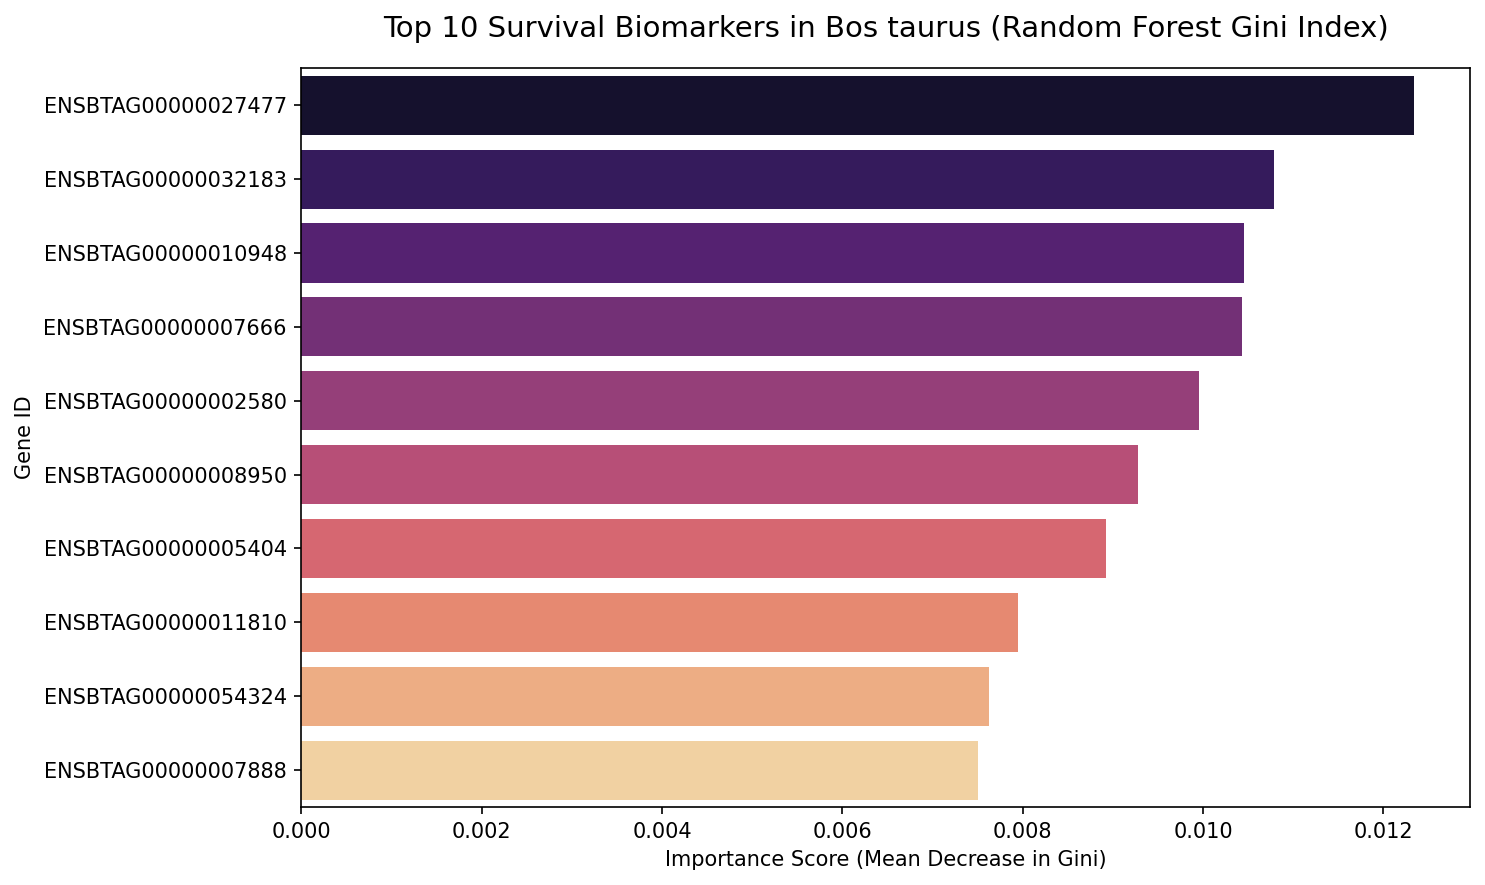

In [9]:
# 8. VISUALIZE TOP 10
print("\n TOP 10 COW HEAT-STRESS SURVIVAL GENES:")
display(top_cow.head(10))

plt.figure(figsize=(10, 6), dpi=150)
# Updated seaborn code to prevent that pink warning message!
sns.barplot(x='Gini_Importance_Score', y='Gene_ID', data=top_cow.head(10), hue='Gene_ID', palette='magma', legend=False)
plt.title("Top 10 Survival Biomarkers in Bos taurus (Random Forest Gini Index)", fontsize=14, pad=15)
plt.xlabel("Importance Score (Mean Decrease in Gini)")
plt.ylabel("Gene ID")
plt.tight_layout()
plt.savefig("../04_Results/Visualizations/Cow_Top10_Biomarkers.png")
plt.show()